# Unique cis-eQTL gene level enrichment

**Grain**: unique `Source_gene` alone - collapsed across `Source_module` and
`program`. This is DISTINCT from the `(Source_module, Source_gene, program)`
grain used throughout the rest of this project, which is now consistently
called "cis/trans network" (see `Factor_ER_v3.ipynb`) to avoid the naming
collision that caused the "cis-eQTL" and "cis/trans network" panels to be
identical in an earlier version of the combined figure - they were
accidentally testing the exact same grain under two different names.

Within-only/Across-only composition and all 14 resource x direction
categories are re-derived at this coarser grain (any instance of a gene,
across all its modules/programs, counts). Blood-exosome membership is
pulled directly from the existing per-factor `cis_eqtl_factors` table via
`ANY()` per gene - an exact aggregation, not an approximation, since
exosome membership is already a gene-level property that never varies by
module/program.


# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("ggplot2"))
suppressMessages(library("scales"))


# PATH

In [2]:
master_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/"
outdir <- paste0(master_dir, "cis_eQTL_gene_level/")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
cat("Created:", outdir, "\n")


Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_gene_level/ 


# Load data

`whole_eqtl_annotated.rds` for the edge-level source data, and the existing
`(Source_module, Source_gene, program)`-grain exosome bundle, purely to pull
gene-level exosome membership from (via `ANY()` per gene) rather than
re-deriving it from the raw exoRBase file again.

In [3]:
whole_eqtl_annotated <- readRDS(paste0(master_dir, "whole_eqtl_annotated.rds"))
cat("whole_eqtl_annotated:", nrow(whole_eqtl_annotated), "rows\n")

cis_eqtl_bundle_path <- paste0(master_dir, "cis_eQTL_level_exosome/cis_eqtl_exosome_results_bundle.rds")
results_bundle <- readRDS(cis_eqtl_bundle_path)
cis_eqtl_factors <- results_bundle$cis_eqtl_factors
cat("cis_eqtl_factors (module/program grain, for exosome lookup only):", nrow(cis_eqtl_factors), "rows\n")


whole_eqtl_annotated: 305496 rows
cis_eqtl_factors (module/program grain, for exosome lookup only): 3167 rows


# Step 1: Gene-level topology (Source_gene alone, full graph)

Mixed-composition genes are excluded from testing, same convention as
every other level in this project.

In [5]:
gene_topology <- whole_eqtl_annotated[
  , .(n_within = sum(edge.type == "Within"), n_across = sum(edge.type == "Across")),
  by = .(Source_gene)
]
gene_topology[, edge_type_composition := fcase(
  n_within > 0 & n_across == 0, "Within-only",
  n_across > 0 & n_within == 0, "Across-only",
  n_within > 0 & n_across > 0,  "Mixed"
)]

cat("Gene-level composition (all cis-eQTL genes):\n")
print(gene_topology[, .N, by = edge_type_composition])

## NOTE: unlike every other level in this project, Mixed genes are KEPT here
## (not excluded) - annotation and the composition barplot use ALL genes;
## only the individual Fisher tests below subset to the relevant pair of
## groups each time.
gene_factors_all <- copy(gene_topology)
cat("\nTotal genes carried forward (Mixed included):", nrow(gene_factors_all), "\n")

Gene-level composition (all cis-eQTL genes):
   edge_type_composition     N
                  <char> <int>
1:           Within-only   520
2:           Across-only   427
3:                 Mixed   205

Total genes carried forward (Mixed included): 1152 


# Step 2: Annotate genes with the 14 resource x direction categories

Same regexes as every other level in this project (CollecTRI, SCENIC
activator/repressor, RBP, Liana L-R, MEROPS, each forward/reverse; PPI
undirected, strict/lenient bands), now grouped by `Source_gene` only.

In [6]:
## Regexes unchanged from before
collectri_forward_regex  <- "Source_TF->Target"
collectri_reverse_regex  <- "Target_TF->Source"
scenic_act_forward_regex <- "Source_TF_activator->Target"
scenic_act_reverse_regex <- "Target_TF_activator->Source"
scenic_rep_forward_regex <- "Source_TF_repressor->Target"
scenic_rep_reverse_regex <- "Target_TF_repressor->Source"
rbp_forward_regex <- "Source_RBP->Target"
rbp_reverse_regex <- "Target_RBP->Source"
liana_forward_regex  <- "Source_Ligand->Target_Receptor"
liana_reverse_regex  <- "Target_Ligand->Source_Receptor"
merops_forward_regex <- "Source_Peptidase->Target_Substrate"
merops_reverse_regex <- "Target_Peptidase->Source_Substrate"
ppi_strict_pattern  <- "PPI (STRING_experimental >=0.4)"
ppi_lenient_pattern <- "PPI (STRING_experimental >=0.1 <0.4)"

gene_annotation <- whole_eqtl_annotated[
  gene_factors_all[, .(Source_gene)],
  on = .(Source_gene), nomatch = 0
][, .(
    has_CollecTRI_source        = any(!is.na(edge_role) & grepl(collectri_forward_regex, edge_role, fixed = TRUE)),
    has_CollecTRI_target        = any(!is.na(edge_role) & grepl(collectri_reverse_regex, edge_role, fixed = TRUE)),
    has_SCENIC_activator_source = any(!is.na(edge_role) & grepl(scenic_act_forward_regex, edge_role, fixed = TRUE)),
    has_SCENIC_activator_target = any(!is.na(edge_role) & grepl(scenic_act_reverse_regex, edge_role, fixed = TRUE)),
    has_SCENIC_repressor_source = any(!is.na(edge_role) & grepl(scenic_rep_forward_regex, edge_role, fixed = TRUE)),
    has_SCENIC_repressor_target = any(!is.na(edge_role) & grepl(scenic_rep_reverse_regex, edge_role, fixed = TRUE)),
    has_RBP_source     = any(!is.na(edge_role) & grepl(rbp_forward_regex, edge_role, fixed = TRUE)),
    has_RBP_target     = any(!is.na(edge_role) & grepl(rbp_reverse_regex, edge_role, fixed = TRUE)),
    has_LR_source       = any(!is.na(edge_role) & grepl(liana_forward_regex, edge_role, fixed = TRUE)),
    has_LR_target       = any(!is.na(edge_role) & grepl(liana_reverse_regex, edge_role, fixed = TRUE)),
    has_MEROPS_source   = any(!is.na(edge_role) & grepl(merops_forward_regex, edge_role, fixed = TRUE)),
    has_MEROPS_target   = any(!is.na(edge_role) & grepl(merops_reverse_regex, edge_role, fixed = TRUE)),
    has_PPI_strict      = any(!is.na(edge_role) & grepl(ppi_strict_pattern, edge_role, fixed = TRUE)),
    has_PPI_lenient     = any(!is.na(edge_role) & grepl(ppi_lenient_pattern, edge_role, fixed = TRUE))
  ), by = .(Source_gene)]

gene_factors_all <- merge(gene_factors_all, gene_annotation, by = "Source_gene", all.x = TRUE)
stopifnot(nrow(gene_factors_all) == nrow(gene_annotation))

# Step 3: Blood-exosome membership (pulled from the module/program-grain table)

`ANY()` per `Source_gene` is an exact aggregation here, not an approximation
- `has_exosome_blood_healthy` never varies within a gene across
modules/programs in `cis_eqtl_factors`, since it's a property of the gene
itself (blood-EVP detection frequency), not of the factor.

In [7]:
exosome_per_gene <- cis_eqtl_factors[, .(has_exosome_blood_healthy = any(has_exosome_blood_healthy),
                                          exosome_assessed = any(exosome_assessed)), by = Source_gene]
gene_factors_all <- merge(gene_factors_all, exosome_per_gene, by = "Source_gene", all.x = TRUE)

n_not_assessed <- sum(!gene_factors_all$exosome_assessed, na.rm = TRUE)
cat("Genes with no exoRBase healthy-EVP data at all:", n_not_assessed, "/", nrow(gene_factors_all), "\n")

Genes with no exoRBase healthy-EVP data at all: 29 / 1152 


# Step 4: Fisher's exact test

Same convention as every other level: explicit factor level order fixes
OR = odds(Across)/odds(Within), zero-hit rows return `status =
"insufficient_data"` handled generically rather than assumed absent.

In [8]:
## Generalized: compares group_b vs group_a explicitly (OR = odds(group_b)/odds(group_a)),
## with an explicit factor level order so the direction never depends on
## table()'s default alphabetical sort - same principle as every other Fisher
## test in this project, just parameterized instead of hardcoded to
## Within-only/Across-only.
run_fisher_comparison_2groups <- function(dt, category_col, group_a, group_b) {
  dt_sub <- dt[edge_type_composition %in% c(group_a, group_b)]
  comp_factor <- factor(dt_sub$edge_type_composition, levels = c(group_a, group_b))
  tab <- table(comp_factor, dt_sub[[category_col]])
  if (!"TRUE"  %in% colnames(tab)) tab <- cbind(tab, "TRUE" = 0)
  if (!"FALSE" %in% colnames(tab)) tab <- cbind(tab, "FALSE" = 0)
  tab <- tab[, c("FALSE", "TRUE")]
  if (!all(c(group_a, group_b) %in% rownames(tab))) {
    return(data.table(category = category_col, status = "insufficient_data"))
  }
  ft <- fisher.test(tab)
  data.table(
    category = category_col,
    n_a_pos = tab[group_a, "TRUE"], n_a_total = sum(tab[group_a, ]),
    n_b_pos = tab[group_b, "TRUE"], n_b_total = sum(tab[group_b, ]),
    odds_ratio = unname(ft$estimate), ci_low = ft$conf.int[1], ci_high = ft$conf.int[2],
    p_value = ft$p.value
  )
}

gene_level_categories <- c("has_CollecTRI_source", "has_CollecTRI_target",
                            "has_SCENIC_activator_source", "has_SCENIC_activator_target",
                            "has_SCENIC_repressor_source", "has_SCENIC_repressor_target",
                            "has_RBP_source", "has_RBP_target",
                            "has_LR_source", "has_LR_target",
                            "has_MEROPS_source", "has_MEROPS_target",
                            "has_PPI_strict", "has_PPI_lenient")

## --- Comparison 1: Across-only vs Within-only ---
fisher_across_vs_within <- rbindlist(lapply(gene_level_categories, function(cat_col)
  run_fisher_comparison_2groups(gene_factors_all, cat_col, "Within-only", "Across-only")), fill = TRUE)
exosome_awv <- run_fisher_comparison_2groups(gene_factors_all[exosome_assessed == TRUE | is.na(exosome_assessed)],
                                               "has_exosome_blood_healthy", "Within-only", "Across-only")
fisher_across_vs_within <- rbind(fisher_across_vs_within, exosome_awv, fill = TRUE)
fisher_across_vs_within[, comparison := "Across vs Within"]

## --- Comparison 2: Mixed vs Within-only ---
fisher_mixed_vs_within <- rbindlist(lapply(gene_level_categories, function(cat_col)
  run_fisher_comparison_2groups(gene_factors_all, cat_col, "Within-only", "Mixed")), fill = TRUE)
exosome_mvw <- run_fisher_comparison_2groups(gene_factors_all[exosome_assessed == TRUE | is.na(exosome_assessed)],
                                               "has_exosome_blood_healthy", "Within-only", "Mixed")
fisher_mixed_vs_within <- rbind(fisher_mixed_vs_within, exosome_mvw, fill = TRUE)
fisher_mixed_vs_within[, comparison := "Mixed vs Within"]

gene_fisher_all <- rbind(fisher_across_vs_within, fisher_mixed_vs_within, fill = TRUE)
if (!"status" %in% names(gene_fisher_all)) gene_fisher_all[, status := NA_character_]
gene_fisher_all[, p_adj_BH := NA_real_]
gene_fisher_all[comparison == "Across vs Within" & (is.na(status) | status != "insufficient_data"),
                p_adj_BH := p.adjust(p_value, method = "BH")]
gene_fisher_all[comparison == "Mixed vs Within" & (is.na(status) | status != "insufficient_data"),
                p_adj_BH := p.adjust(p_value, method = "BH")]

print(gene_fisher_all)

                       category n_a_pos n_a_total n_b_pos n_b_total odds_ratio
                         <char>   <num>     <num>   <num>     <num>      <num>
 1:        has_CollecTRI_source       7       520       1       427  0.1722756
 2:        has_CollecTRI_target       8       520       3       427  0.4531895
 3: has_SCENIC_activator_source      15       520       4       427  0.3187111
 4: has_SCENIC_activator_target      67       520      25       427  0.4208321
 5: has_SCENIC_repressor_source       8       520       2       427  0.3015141
 6: has_SCENIC_repressor_target      17       520      27       427  1.9957689
 7:              has_RBP_source       1       520       1       427  1.2180498
 8:              has_RBP_target      14       520      14       427  1.2249121
 9:               has_LR_source       4       520       1       427  0.3031532
10:               has_LR_target       1       520       2       427  2.4401088
11:           has_MEROPS_source       0       520   

# Step 5: Save results table

In [9]:
fwrite(gene_fisher_all, paste0(outdir, "cis_eqtl_gene_level_fisher_results.tsv"), sep = "\t")
saveRDS(gene_fisher_all, paste0(outdir, "cis_eqtl_gene_level_fisher_results.rds"))
cat("Saved to", outdir, "\n")


Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_gene_level/ 


# Step 6: Row labels, order, colors

Recycled verbatim from the shared scheme used across every other level in
this project, so this plot is directly row-for-row comparable.

In [12]:
resource_colors <- c(
  "CollecTRI" = "#D55E00", "SCENIC_activator" = "orange", "SCENIC_repressor" = "black",
  "RBP" = "#CC79A7", "LR" = "#009E73", "PPI" = "#0072B2", "MEROPS" = "grey50", "Exosome" = "purple"
)
resource_legend_labels_with_exosome <- c(
  "CollecTRI" = "CollecTRI", "SCENIC_activator" = "SCENIC activator", "SCENIC_repressor" = "SCENIC repressor",
  "RBP" = "RBP (POSTAR3)", "LR" = "Liana L-R", "MEROPS" = "MEROPS\nPeptidase-substrate", "PPI" = "PPI (STRING)",
  "Exosome" = "Blood exosome (healthy donor)"
)

row_order_top_to_bottom <- c(
  "TF-target (CollecTRI)\ncis-eQTL \u2192 trans-eQTL",
  "TF-target (CollecTRI)\ntrans-eQTL \u2192 cis-eQTL",
  "activator TF-target (SCENIC)\ncis-eQTL \u2192 trans-eQTL",
  "activator TF-target (SCENIC)\ntrans-eQTL \u2192 cis-eQTL",
  "repressor TF-target (SCENIC)\ncis-eQTL \u2192 trans-eQTL",
  "repressor TF-target (SCENIC)\ntrans-eQTL \u2192 cis-eQTL",
  "RBP-target (POSTAR3)\ncis-eQTL \u2192 trans-eQTL",
  "RBP-target (POSTAR3)\ntrans-eQTL \u2192 cis-eQTL",
  "Ligand-Receptor (Liana)\ncis-eQTL \u2192 trans-eQTL",
  "Ligand-Receptor (Liana)\ntrans-eQTL \u2192 cis-eQTL",
  "Peptidase-substrate (MEROPS)\ncis-eQTL \u2192 trans-eQTL",
  "Peptidase-substrate (MEROPS)\ntrans-eQTL \u2192 cis-eQTL",
  "PPI (STRING, experimental)\n0.1 < score <= 0.4\nUndirected (PPI)",
  "PPI (STRING, experimental)\nscore >= 0.4\nUndirected (PPI)",
  "Blood exosome\n(healthy donor)"
)
axis_limits_bottom_to_top <- rev(row_order_top_to_bottom)

direction_display_labels <- c(
  "forward" = "cis-eQTL \u2192 trans-eQTL", "reverse" = "trans-eQTL \u2192 cis-eQTL", "undirected" = "Undirected (PPI)"
)

category_map <- data.table(
  category = gene_level_categories,
  resource_display_val = c("TF-target (CollecTRI)", "TF-target (CollecTRI)",
                            "activator TF-target (SCENIC)", "activator TF-target (SCENIC)",
                            "repressor TF-target (SCENIC)", "repressor TF-target (SCENIC)",
                            "RBP-target (POSTAR3)", "RBP-target (POSTAR3)",
                            "Ligand-Receptor (Liana)", "Ligand-Receptor (Liana)",
                            "Peptidase-substrate (MEROPS)", "Peptidase-substrate (MEROPS)",
                            "PPI (STRING, experimental)", "PPI (STRING, experimental)"),
  direction_val = c("forward","reverse","forward","reverse","forward","reverse",
                     "forward","reverse","forward","reverse","forward","reverse",
                     "undirected","undirected"),
  ppi_score_val = c(NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,"score >= 0.4","0.1 < score <= 0.4"),
  resource_key = c("CollecTRI","CollecTRI","SCENIC_activator","SCENIC_activator",
                    "SCENIC_repressor","SCENIC_repressor","RBP","RBP","LR","LR",
                    "MEROPS","MEROPS","PPI","PPI")
)
category_map[, row_label := fifelse(is.na(ppi_score_val),
  paste(resource_display_val, direction_display_labels[direction_val], sep = "\n"),
  paste(resource_display_val, ppi_score_val, direction_display_labels["undirected"], sep = "\n"))]

category_map <- rbind(category_map,
  data.table(category = "has_exosome_blood_healthy", resource_display_val = NA, direction_val = NA,
             ppi_score_val = NA, resource_key = "Exosome", row_label = "Blood exosome\n(healthy donor)"))

cat("Category row_labels NOT in the recycled order (should be empty):\n")
print(setdiff(unique(category_map$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(category_map$row_label), row_order_top_to_bottom)) == 0)

Category row_labels NOT in the recycled order (should be empty):
character(0)


# Step 7: Build the plotted odds-ratio and composition tables

In [13]:
x_axis_floor_or <- 0.05

ce_odds_data <- merge(gene_fisher_all, category_map, by = "category")
ce_odds_data[, n_pos := n_a_pos + n_b_pos]
ce_odds_data[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]
ce_odds_data[, is_zero_hit := !is.na(odds_ratio) & (odds_ratio == 0 | !is.finite(odds_ratio))]
ce_odds_data[, is_not_applicable := is.na(odds_ratio) & is_zero_hit == FALSE]
ce_odds_data[, x_plot_final := fifelse(is_zero_hit, x_axis_floor_or, odds_ratio)]
ce_odds_data[, ci_low_plot := fifelse(is_zero_hit, NA_real_, ci_low)]
ce_odds_data[, ci_high_plot := fifelse(is_zero_hit, NA_real_, ci_high)]
ce_odds_data[, comparison := factor(comparison, levels = c("Across vs Within", "Mixed vs Within"))]

cat("Rows per comparison:\n")
print(table(ce_odds_data$comparison))

Rows per comparison:

Across vs Within  Mixed vs Within 
              15               15 


# Step 8: Odds-ratio forest plot

In [14]:
all_categories_incl_exosome <- c(gene_level_categories, "has_exosome_blood_healthy")

composition_group_counts <- rbindlist(lapply(all_categories_incl_exosome, function(cat_col) {
  dt_use <- if (cat_col == "has_exosome_blood_healthy") gene_factors_all[exosome_assessed == TRUE] else gene_factors_all
  tab <- dt_use[, .(n_pos = sum(get(cat_col), na.rm = TRUE)), by = edge_type_composition]
  tab[, category := cat_col]
  tab
}), fill = TRUE)

composition_group_counts <- merge(composition_group_counts, category_map[, .(category, row_label)], by = "category")
composition_group_counts[, n_total_pos := sum(n_pos), by = row_label]
composition_group_counts[, pct := 100 * n_pos / n_total_pos]
composition_group_counts[, edge_type_composition := factor(edge_type_composition,
                                                              levels = c("Within-only", "Across-only", "Mixed"))]

ce_comp_data <- composition_group_counts[, .(row_label, n_total_pos, composition_type = edge_type_composition, pct)]

total_cis_eqtl_gene_n <- nrow(gene_factors_all)
cat("total_cis_eqtl_gene_n (ALL genes, Within-only + Across-only + Mixed):", total_cis_eqtl_gene_n, "\n")

total_cis_eqtl_gene_n (ALL genes, Within-only + Across-only + Mixed): 1152 


# Step 9: Composition stacked barplot

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

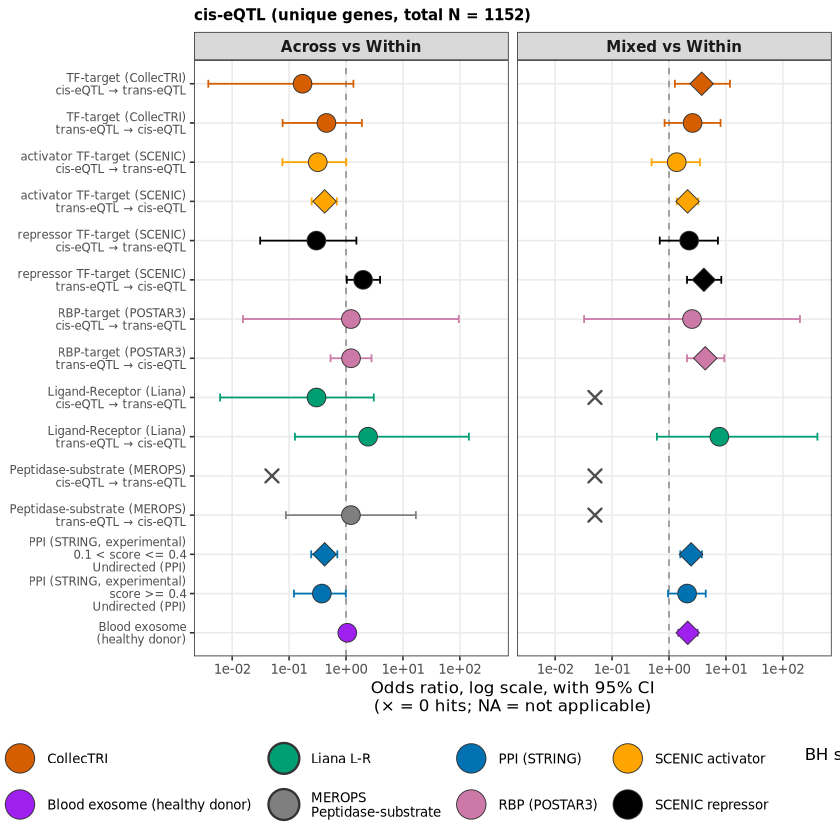

In [15]:
p_gene_level_odds <- ggplot(ce_odds_data, aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(data = ce_odds_data[is_zero_hit == FALSE & is_not_applicable == FALSE],
             aes(fill = resource_key, shape = sig_BH_05), color = "grey20", stroke = 0.4, size = 5) +
  geom_point(data = ce_odds_data[is_zero_hit == TRUE],
             aes(fill = resource_key), shape = 4, size = 3, color = "grey30", stroke = 1) +
  geom_text(data = ce_odds_data[is_not_applicable == TRUE], aes(x = 1), label = "NA",
            color = "grey40", size = 3, fontface = "italic") +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)", na.translate = FALSE) +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels_with_exosome) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  facet_grid(cols = vars(comparison)) +
  labs(x = "Odds ratio, log scale, with 95% CI\n(\u00d7 = 0 hits; NA = not applicable)",
       y = NULL, title = paste0("cis-eQTL (unique genes, total N = ", total_cis_eqtl_gene_n, ")")) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_text(size = 7), panel.grid.minor = element_blank(),
        legend.position = "bottom", plot.title = element_text(size = 9, face = "bold"),
        strip.text = element_text(size = 9, face = "bold")) +
  guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))

ggsave(paste0(outdir, "cis_eqtl_gene_level_forest.png"), p_gene_level_odds, width = 12,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "cis_eqtl_gene_level_forest.pdf"), p_gene_level_odds, width = 12,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_gene_level_odds

# Step 10: Combine (75:25) and save

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved bundle to: /nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_gene_level/cis_eqtl_gene_level_bundle.rds 


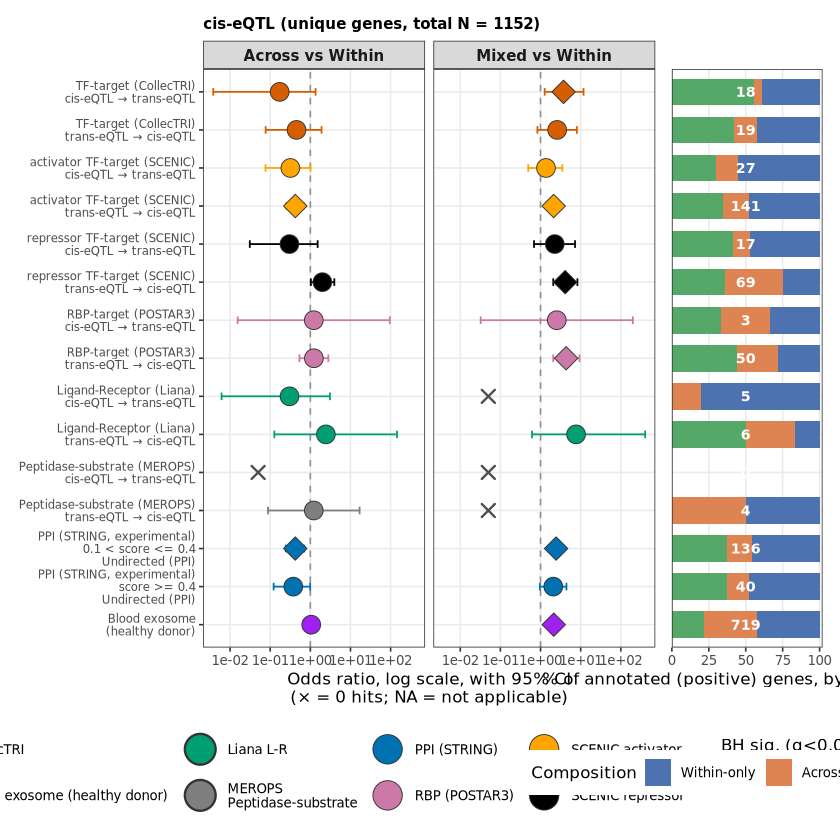

In [16]:
within_across_mixed_colors <- c("Within-only" = "#4C72B0", "Across-only" = "#DD8452", "Mixed" = "#55A868")

p_gene_level_comp <- ggplot(ce_comp_data, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(
    data = unique(ce_comp_data[!is.na(n_total_pos), .(row_label, n_total_pos)]),
    aes(x = 50, y = row_label, label = n_total_pos),
    inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold"
  ) +
  scale_fill_manual(values = within_across_mixed_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 25, 50, 75, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  labs(x = "% of annotated (positive) genes, by composition", y = NULL) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        panel.grid.minor = element_blank(), legend.position = "bottom")

suppressMessages(library(patchwork))
p_gene_level_side_by_side <- (p_gene_level_odds | p_gene_level_comp) + plot_layout(widths = c(3, 1))

ggsave(paste0(outdir, "cis_eqtl_gene_level_combined.png"), p_gene_level_side_by_side, width = 15,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "cis_eqtl_gene_level_combined.pdf"), p_gene_level_side_by_side, width = 15,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

cis_eqtl_gene_level_bundle <- list(
  gene_fisher_all = gene_fisher_all,
  ce_odds_data = ce_odds_data,
  ce_comp_data = ce_comp_data,
  gene_factors_all = gene_factors_all,
  plot_metadata = list(
    resource_colors = resource_colors,
    resource_legend_labels_with_exosome = resource_legend_labels_with_exosome,
    row_order_top_to_bottom = row_order_top_to_bottom,
    axis_limits_bottom_to_top = axis_limits_bottom_to_top,
    category_map = category_map,
    within_across_mixed_colors = within_across_mixed_colors,
    level_name = "cis-eQTL (unique genes)",
    grain_definition = "Source_gene alone, collapsed across Source_module and program",
    total_n = total_cis_eqtl_gene_n,
    comparisons = "Two independent Fisher families: Across-only vs Within-only, Mixed vs Within-only (BH-corrected separately)",
    odds_ratio_convention = "OR = odds(category present | comparison group) / odds(category present | Within-only)",
    generated_on = Sys.time(),
    r_session = capture.output(sessionInfo())
  )
)
saveRDS(cis_eqtl_gene_level_bundle, paste0(outdir, "cis_eqtl_gene_level_bundle.rds"))
cat("Saved bundle to:", paste0(outdir, "cis_eqtl_gene_level_bundle.rds"), "\n")

p_gene_level_side_by_side

# Step 11: Save bundle for use in Global_ER_replotting.ipynb

Same pattern as the other level bundles - raw results, plotted tables, and
metadata in one RDS, so the combined three(+one)-level figure can load this
directly without rerunning any derivation here.

In [17]:
## =============================================================================
## Save data tables for Global_ER_replotting.ipynb, with an explicit flag
## that "Mixed" is a category unique to this level - the gene-pair and
## cis/trans network levels only ever have Within-only/Across-only rows
## (Mixed is structurally absent there, per Methods.md), so the combined
## three-level legend will show a category with no counterpart in the other
## two panels. This must be handled explicitly there, not silently.
## =============================================================================
cis_eqtl_gene_level_bundle <- list(
  gene_fisher_all = gene_fisher_all,
  ce_odds_data = ce_odds_data,
  ce_comp_data = ce_comp_data,
  gene_factors_all = gene_factors_all,
  plot_metadata = list(
    resource_colors = resource_colors,
    resource_legend_labels_with_exosome = resource_legend_labels_with_exosome,
    row_order_top_to_bottom = row_order_top_to_bottom,
    axis_limits_bottom_to_top = axis_limits_bottom_to_top,
    category_map = category_map,
    within_across_mixed_colors = within_across_mixed_colors,

    level_name = "cis-eQTL (unique genes)",
    grain_definition = "Source_gene alone, collapsed across Source_module and program",
    total_n = total_cis_eqtl_gene_n,
    comparisons = "Two independent Fisher families: Across-only vs Within-only, Mixed vs Within-only (BH-corrected separately)",
    odds_ratio_convention = "OR = odds(category present | comparison group) / odds(category present | Within-only)",

    ## Explicit flag for the combined-figure legend logic downstream
    has_mixed_category = TRUE,
    mixed_category_note = paste(
      "The 'Mixed' composition category exists ONLY at this level (unique",
      "cis-eQTL genes). The gene-pair-collapsed level and the cis/trans",
      "network level both classify only Within-only/Across-only factors,",
      "with zero Mixed rows by construction (see Methods.md). When building",
      "a combined legend across all three levels, 'Mixed' should be included",
      "once (sourced from this level) and NOT expected to appear in, or be",
      "silently dropped from, the other two levels' color scales."
    ),

    generated_on = Sys.time(),
    r_session = capture.output(sessionInfo())
  )
)
saveRDS(cis_eqtl_gene_level_bundle, paste0(outdir, "cis_eqtl_gene_level_bundle.rds"))

## Human-readable companions
fwrite(gene_fisher_all, paste0(outdir, "cis_eqtl_gene_level_fisher_all.tsv"), sep = "\t")
fwrite(ce_odds_data, paste0(outdir, "cis_eqtl_gene_level_odds_plotted.tsv"), sep = "\t")
fwrite(ce_comp_data, paste0(outdir, "cis_eqtl_gene_level_composition_plotted.tsv"), sep = "\t")

cat("Saved bundle to:", paste0(outdir, "cis_eqtl_gene_level_bundle.rds"), "\n")
cat("Saved companions: cis_eqtl_gene_level_fisher_all.tsv, cis_eqtl_gene_level_odds_plotted.tsv, cis_eqtl_gene_level_composition_plotted.tsv\n")

Saved bundle to: /nfs/team151/mt19/overhaul_classification_factors_with_programs/cis_eQTL_gene_level/cis_eqtl_gene_level_bundle.rds 
Saved companions: cis_eqtl_gene_level_fisher_all.tsv, cis_eqtl_gene_level_odds_plotted.tsv, cis_eqtl_gene_level_composition_plotted.tsv


In [18]:
## =============================================================================
## Full numeric summary: all categories x both comparisons (Across vs Within,
## Mixed vs Within), with direction and concordance flags for reporting.
## =============================================================================
gene_fisher_summary <- copy(gene_fisher_all)
gene_fisher_summary[, direction := fifelse(is.na(odds_ratio), NA_character_,
                                             fifelse(odds_ratio > 1, "enriched in comparison group",
                                             fifelse(odds_ratio < 1, "enriched in Within-only", "no difference (OR=1)")))]

## Wide format: one row per category, both comparisons side by side, so
## direction concordance can be read directly.
gene_fisher_wide <- dcast(
  gene_fisher_summary,
  category ~ comparison,
  value.var = c("odds_ratio", "ci_low", "ci_high", "p_value", "p_adj_BH", "direction", "status")
)

gene_fisher_wide[, direction_concordant := fifelse(
  is.na(`direction_Across vs Within`) | is.na(`direction_Mixed vs Within`), NA,
  `direction_Across vs Within` == `direction_Mixed vs Within`
)]

## Join in the readable row_label/resource_key for reference
gene_fisher_wide <- merge(gene_fisher_wide, category_map[, .(category, row_label, resource_key)], by = "category")
setcolorder(gene_fisher_wide, c("category", "row_label", "resource_key"))

cat("=== Full numeric summary, all 15 categories ===\n")
print(gene_fisher_wide, digits = 4)

=== Full numeric summary, all 15 categories ===
Key: <category>
                       category
                         <char>
 1:        has_CollecTRI_source
 2:        has_CollecTRI_target
 3:               has_LR_source
 4:               has_LR_target
 5:           has_MEROPS_source
 6:           has_MEROPS_target
 7:             has_PPI_lenient
 8:              has_PPI_strict
 9:              has_RBP_source
10:              has_RBP_target
11: has_SCENIC_activator_source
12: has_SCENIC_activator_target
13: has_SCENIC_repressor_source
14: has_SCENIC_repressor_target
15:   has_exosome_blood_healthy
                                                           row_label
                                                              <char>
 1:                     TF-target (CollecTRI)\ncis-eQTL → trans-eQTL
 2:                     TF-target (CollecTRI)\ntrans-eQTL → cis-eQTL
 3:                   Ligand-Receptor (Liana)\ncis-eQTL → trans-eQTL
 4:                   Ligand-Receptor (Liana)\n